# Revision Figures

Three figures for the PepBind3D revision.

- **Figure A** - peptide-HLA pairs per allele across the whole v2 dataset (37
  released HLA-A/B alleles + 11 new HLA-C alleles), released vs. new visually
  distinguished.
- **Figure B** - distribution of peptide-backbone RMSD per structure-prediction
  model (Rosetta docking now; AF2/Boltz-2/Boltz-1/Chai-1 co-folding arms are
  still running and are picked up automatically once their results land).
- **Figure C** - sampling convergence: expected best-of-n RMSD as a function
  of decoy count n = 1..25, bootstrapped over the 25-decoy ensembles, to
  check whether 25 decoys was enough sampling.

All panels save to `figures/` next to this notebook at 300 dpi (PNG + PDF)
and are also shown inline. No cluster jobs are submitted by this notebook.


## Setup

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Make the local utils package importable (project convention, see 01/07)
sys.path.insert(0, str(Path.cwd()))
from utils import set_plot_style

set_plot_style()

# === Figure sizing (Scientific Data conventions, matches 04_figure1_panels.ipynb) ===
MM = 1 / 25.4
COL1_WIDTH = 89 * MM    # ~3.5 in, single column
COL2_WIDTH = 183 * MM   # ~7.2 in, double column

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "axes.linewidth":  0.8,
    "xtick.major.width": 0.8,
    "ytick.major.width": 0.8,
})

FIG_DIR = Path.cwd() / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def savefig(fig, name):
    # Save a figure as PNG (300 dpi) + PDF into figures/, matching house style.
    fig.savefig(FIG_DIR / f"{name}.png", dpi=300)
    fig.savefig(FIG_DIR / f"{name}.pdf")

COLOR_RELEASED = "#4477AA"   # blue, matches 01_structural_validation.ipynb palette
COLOR_NEW      = "#CC3311"   # red/orange accent, same palette
GRID_COLOR     = "#dddddd"

print(f"Figures will be written to: {FIG_DIR}")


Figures will be written to: /panfs/accrepfs.vampire/data/p_csb_meiler/huntek1/PepBind3D_repo/figures


## Figure A - peptide-HLA pairs per allele

**Data sources**

- **Released 37 HLA-A/B alleles.** The dataset's `metadata.csv` was not present
  on this filesystem in this session (checked
  `/home/huntek1/main_project/data/IEDB_data_clean/huggingface/metadata.csv`
  and the released `pdb/` structure tree, which is not fully populated here
  either - only a single-allele stub exists locally). The per-allele
  peptide-HLA pair counts below are instead taken from **Table S5** of this
  repository's own `07_supplemental_tables.ipynb`, which computes them
  directly from `metadata.csv`
  (`df_all.groupby('allele')[['allele','peptide']].drop_duplicates()`,
  counting *all* released records including the 15 flagged ones, matching how
  Table S5/S4 in the manuscript is built). That notebook's cached cell output
  is reproduced verbatim below, with `Peptide-HLA pairs` as the count and
  provenance quoted here rather than silently re-derived. **`metadata.csv`
  itself was not read or modified by this notebook.** Total: 49,268 pairs
  across 37 alleles, matching the abstract figure printed in Table S5's own
  output (`S4 pair total: 49,268`).
- **New 11 HLA-C alleles.** Counted live, read-only, from
  `/data/p_csb_meiler/huntek1/hlac_production/pdb/`, where each
  `{allele_dir}/{peptide}/` subdirectory is one peptide-HLA pair (directory
  names are flattened, e.g. `C0401` = `C*04:01`). This mirrors exactly how
  the released A/B pair counts are defined (one modeled peptide-allele
  ensemble = one pair).


In [2]:
# --- Released HLA-A/B pairs: reproduced from 07_supplemental_tables.ipynb Table S5 ---
# (that notebook's own cached output, computed from metadata.csv; see markdown above)
released_ab_pairs = {
    "A*02:01": 9102, "A*68:02": 3457, "A*03:01": 3097, "B*15:01": 2802,
    "A*11:01": 2508, "B*07:02": 2441, "A*01:01": 2313, "B*58:01": 2078,
    "A*26:01": 1994, "B*57:01": 1954, "A*31:01": 1864, "B*27:05": 1836,
    "B*18:01": 1664, "B*40:01": 1658, "B*08:01": 1489, "B*51:01": 1311,
    "B*39:01": 1307, "A*24:02": 1102, "B*44:02":  913, "A*25:01":  902,
    "A*29:02":  825, "B*35:01":  693, "A*23:01":  538, "A*30:01":  498,
    "B*53:01":  216, "B*44:03":  141, "B*38:01":  138, "A*68:01":  124,
    "B*14:02":   86, "A*30:02":   82, "B*40:02":   73, "B*37:01":   30,
    "B*45:01":   20, "B*52:01":    7, "B*42:01":    2, "B*35:03":    2,
    "B*13:02":    1,
}
assert len(released_ab_pairs) == 37, "expected 37 released HLA-A/B alleles"
assert sum(released_ab_pairs.values()) == 49268, "Table S5 total mismatch"
print(f"Released HLA-A/B: {len(released_ab_pairs)} alleles, "
      f"{sum(released_ab_pairs.values()):,} pairs")


Released HLA-A/B: 37 alleles, 49,268 pairs


In [3]:
# --- New HLA-C pairs: counted live, read-only, from the production PDB tree ---
HLAC_PDB_ROOT = Path("/data/p_csb_meiler/huntek1/hlac_production/pdb")

def hlac_dir_to_allele(dirname):
    # "C0401" -> "C*04:01"
    return f"{dirname[0]}*{dirname[1:3]}:{dirname[3:5]}"

new_c_pairs = {}
for allele_dir in sorted(p.name for p in HLAC_PDB_ROOT.iterdir() if p.is_dir()):
    n_peptides = sum(1 for p in (HLAC_PDB_ROOT / allele_dir).iterdir() if p.is_dir())
    new_c_pairs[hlac_dir_to_allele(allele_dir)] = n_peptides

new_c_pairs = dict(sorted(new_c_pairs.items(), key=lambda kv: -kv[1]))
print(f"New HLA-C: {len(new_c_pairs)} alleles, {sum(new_c_pairs.values()):,} pairs")
for allele, n in new_c_pairs.items():
    print(f"  {allele}: {n}")


New HLA-C: 11 alleles, 1,861 pairs
  C*04:01: 506
  C*14:02: 232
  C*06:02: 211
  C*15:02: 181
  C*12:03: 171
  C*05:01: 169
  C*03:03: 161
  C*07:02: 139
  C*08:02: 86
  C*01:02: 4
  C*07:01: 1


Total alleles plotted: 48
Total pairs plotted:   51,129
Dynamic range:         1-9102


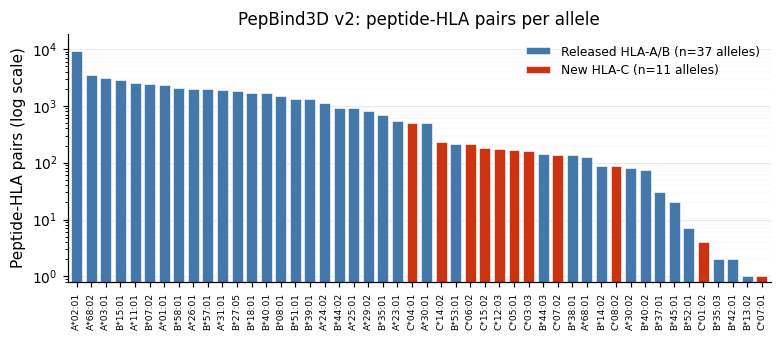

In [4]:
# --- Combine and plot ---
allele_counts = pd.DataFrame(
    [(a, n, False) for a, n in released_ab_pairs.items()] +
    [(a, n, True)  for a, n in new_c_pairs.items()],
    columns=["allele", "pairs", "is_new"],
).sort_values("pairs", ascending=False).reset_index(drop=True)

print(f"Total alleles plotted: {len(allele_counts)}")
print(f"Total pairs plotted:   {allele_counts['pairs'].sum():,}")
print(f"Dynamic range:         {allele_counts['pairs'].min()}-{allele_counts['pairs'].max()}")

fig, ax = plt.subplots(figsize=(COL2_WIDTH, 3.2))

colors = [COLOR_NEW if is_new else COLOR_RELEASED for is_new in allele_counts["is_new"]]
x = np.arange(len(allele_counts))
ax.bar(x, allele_counts["pairs"], color=colors, edgecolor="white", linewidth=0.4, width=0.75)

# Dynamic range (1 to >9000) makes a linear axis useless -> log scale.
ax.set_yscale("log")
ax.set_ylim(0.8, allele_counts["pairs"].max() * 2)

ax.set_xticks(x)
ax.set_xticklabels(allele_counts["allele"], rotation=90, fontsize=6)
ax.set_xlim(-0.6, len(allele_counts) - 0.4)

ax.set_ylabel("Peptide-HLA pairs (log scale)")
ax.set_title("PepBind3D v2: peptide-HLA pairs per allele")

ax.yaxis.grid(True, which="major", color=GRID_COLOR, linewidth=0.5, alpha=0.8)
ax.yaxis.grid(True, which="minor", color=GRID_COLOR, linewidth=0.3, alpha=0.4)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(facecolor=COLOR_RELEASED, edgecolor="white",
          label=f"Released HLA-A/B (n={len(released_ab_pairs)} alleles)"),
    Patch(facecolor=COLOR_NEW, edgecolor="white",
          label=f"New HLA-C (n={len(new_c_pairs)} alleles)"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "figureA_pairs_per_allele")
plt.show()


## Figure B - decoy accuracy per model

Peptide-backbone RMSD (groove-superposed, CA pairing by sequence alignment;
see `benchmark/metric/pmhc_rmsd.py`) for every decoy, grouped by model. Only
targets shared with the classical human HLA-A/B/C benchmark set (174
targets; murine and non-classical loci excluded) are scored. Rosetta is
scored now; AlphaFold2, Boltz-2, Boltz-1, and Chai-1 co-folding arms are
still running (`benchmark/cofold_arm/{af2_reuse,boltz2,boltz1,chai1}/`) and
are **not fabricated or placeholdered** here - the loader below simply skips
any model whose `results/arm_decoys.csv` does not exist yet, so this cell
runs correctly today with Rosetta alone and again unchanged once the other
arms finish and land in the same `results/` layout as Rosetta's.


In [5]:
# Candidate result locations. Rosetta's layout (benchmark/rosetta_arm/results/)
# is the established convention; the co-folding arms are expected to land in the
# analogous benchmark/cofold_arm/<model>/results/ location once scoring finishes.
BENCHMARK_ROOT = Path("/data/p_csb_meiler/huntek1/benchmark")

MODEL_RESULT_DIRS = {
    "Rosetta":  BENCHMARK_ROOT / "rosetta_arm" / "results",
    "AF2":      BENCHMARK_ROOT / "cofold_arm" / "af2_reuse" / "results",
    "Boltz-2":  BENCHMARK_ROOT / "cofold_arm" / "boltz2" / "results",
    "Boltz-1":  BENCHMARK_ROOT / "cofold_arm" / "boltz1" / "results",
    "Chai-1":   BENCHMARK_ROOT / "cofold_arm" / "chai1" / "results",
}

MODEL_COLORS = {
    "Rosetta": "#4477AA", "AF2": "#EE6677", "Boltz-2": "#228833",
    "Boltz-1": "#CCBB44", "Chai-1": "#AA3377",
}

decoy_frames = {}
summary_frames = {}
for model, result_dir in MODEL_RESULT_DIRS.items():
    decoys_csv = result_dir / "arm_decoys.csv"
    summary_csv = result_dir / "arm_summary.csv"
    if decoys_csv.is_file() and summary_csv.is_file():
        decoy_frames[model] = pd.read_csv(decoys_csv)
        summary_frames[model] = pd.read_csv(summary_csv)
        print(f"{model:10s}: found  n_targets={summary_frames[model].shape[0]:4d}  "
              f"n_decoys={decoy_frames[model].shape[0]:5d}   ({decoys_csv})")
    else:
        print(f"{model:10s}: not yet available, skipping  ({decoys_csv})")

if not decoy_frames:
    raise RuntimeError("No model results found at all -- expected Rosetta at least.")


Rosetta   : found  n_targets= 158  n_decoys= 3950   (/data/p_csb_meiler/huntek1/benchmark/rosetta_arm/results/arm_decoys.csv)
AF2       : not yet available, skipping  (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/af2_reuse/results/arm_decoys.csv)
Boltz-2   : not yet available, skipping  (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/boltz2/results/arm_decoys.csv)
Boltz-1   : not yet available, skipping  (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/boltz1/results/arm_decoys.csv)
Chai-1    : not yet available, skipping  (/data/p_csb_meiler/huntek1/benchmark/cofold_arm/chai1/results/arm_decoys.csv)


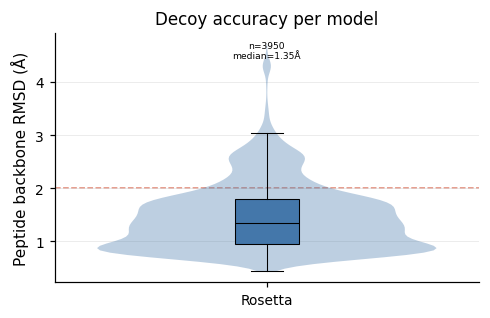

In [6]:
fig, ax = plt.subplots(figsize=(COL1_WIDTH * 1.3, 3.0))

models_present = list(decoy_frames.keys())
positions = np.arange(1, len(models_present) + 1)
rmsd_by_model = [decoy_frames[m]["peptide_backbone_rmsd"].values for m in models_present]

vp = ax.violinplot(rmsd_by_model, positions=positions, showextrema=False, widths=0.8)
for body, model in zip(vp["bodies"], models_present):
    body.set_facecolor(MODEL_COLORS.get(model, "#888888"))
    body.set_edgecolor("none")
    body.set_alpha(0.35)

bp = ax.boxplot(rmsd_by_model, positions=positions, widths=0.15, showfliers=False,
                 patch_artist=True)
for patch, model in zip(bp["boxes"], models_present):
    patch.set_facecolor(MODEL_COLORS.get(model, "#888888"))
    patch.set_edgecolor("black")
    patch.set_linewidth(0.7)
for element in ("whiskers", "caps", "medians"):
    for line in bp[element]:
        line.set_color("black")
        line.set_linewidth(0.7)

ax.axhline(2.0, color="#CC3311", linestyle="--", linewidth=1, alpha=0.6, zorder=0)

ax.set_xticks(positions)
ax.set_xticklabels(models_present)
ax.set_ylabel("Peptide backbone RMSD (\u00c5)")
ax.set_title("Decoy accuracy per model")

for i, m in enumerate(models_present):
    vals = rmsd_by_model[i]
    ax.text(positions[i], ax.get_ylim()[1] * 0.97,
            f"n={len(vals)}\nmedian={np.median(vals):.2f}\u00c5",
            ha="center", va="top", fontsize=6)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()
savefig(fig, "figureB_decoy_accuracy_per_model")
plt.show()


In [7]:
# Rosetta selected/oracle summary, computed live from arm_summary.csv (not hardcoded).
rosetta_summary = summary_frames["Rosetta"]
n_scored = len(rosetta_summary)
mean_selected = rosetta_summary["selected"].mean()
mean_oracle = rosetta_summary["oracle"].mean()
pct_under_2 = (rosetta_summary["selected"] < 2.0).mean() * 100

print(f"Rosetta arm: n={n_scored} targets scored")
print(f"  mean selected-decoy RMSD: {mean_selected:.3f} A")
print(f"  mean oracle (best-of-25) RMSD: {mean_oracle:.3f} A")
print(f"  selected-decoy RMSD < 2 A: {pct_under_2:.1f}%")


Rosetta arm: n=158 targets scored
  mean selected-decoy RMSD: 1.320 A
  mean oracle (best-of-25) RMSD: 1.137 A
  selected-decoy RMSD < 2 A: 89.2%


## Figure C - sampling convergence

The 25 Rosetta decoys per pair were generated to check whether docking had
**converged**, not to argue an ensemble beats a single structure. For each
decoy count n = 1..25, we repeatedly draw a random subset of n decoys
(without replacement) from each target's 25, take the best (lowest) RMSD in
that subset, and average across targets. Repeating this many times
(bootstrap) gives, for each n, the distribution of "expected best-of-n
RMSD" - its mean and a 95% band. If the curve plateaus well before n = 25,
25 decoys was more than enough; if it is still descending at n = 25, more
docking would likely have helped.


In [8]:
rosetta_decoys = decoy_frames["Rosetta"]

# One array of 25 RMSDs per target.
per_target_rmsd = (
    rosetta_decoys
    .groupby("pdb_id")["peptide_backbone_rmsd"]
    .apply(lambda s: s.to_numpy())
)
n_decoys_per_target = per_target_rmsd.apply(len)
assert (n_decoys_per_target == 25).all(), "expected exactly 25 decoys per target"
print(f"{len(per_target_rmsd)} targets, 25 decoys each")

rng = np.random.default_rng(0)
N_BOOTSTRAP = 2000
N_MAX = 25
arrays = per_target_rmsd.to_numpy()  # array of length-25 arrays, one per target
n_targets = len(arrays)

# Vectorized bootstrap: for each target, draw N_BOOTSTRAP random orderings of
# its 25 decoys (via argsort of random noise -> a random permutation without
# replacement), then take the running minimum along each ordering. The
# running min at position n-1 is exactly "best RMSD among a random subset of
# the first n decoys in that ordering", which is distributed identically to
# "best RMSD among a random size-n subset without replacement".
per_target_boot = np.empty((n_targets, N_BOOTSTRAP, N_MAX))
for t, arr in enumerate(arrays):
    perm = np.argsort(rng.random((N_BOOTSTRAP, N_MAX)), axis=1)
    ordered = arr[perm]                              # (N_BOOTSTRAP, N_MAX)
    per_target_boot[t] = np.minimum.accumulate(ordered, axis=1)

boot_means = per_target_boot.mean(axis=0)  # (N_BOOTSTRAP, N_MAX), averaged over targets
curve_mean = boot_means.mean(axis=0)
curve_lo = np.percentile(boot_means, 2.5, axis=0)
curve_hi = np.percentile(boot_means, 97.5, axis=0)
n_values = np.arange(1, N_MAX + 1)


158 targets, 25 decoys each


Best-of-1 (single decoy) mean RMSD:   1.464 A
Best-of-25 (full ensemble) mean RMSD: 1.137 A
Plateau (within 2% of best-of-25, sustained): n = 16
Marginal gain from decoy 16 to 25: 0.022 A


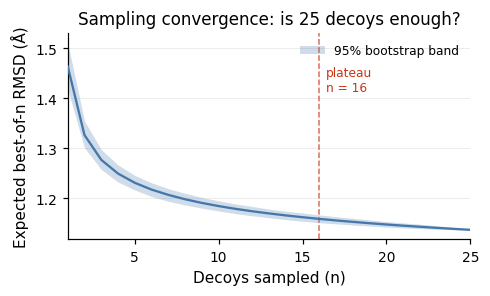

In [9]:
# Where does the curve plateau? First n whose mean is within 2% (relative) of
# the n=25 asymptote, held for all subsequent n.
asymptote = curve_mean[-1]
tol = 0.02 * asymptote
within_tol = np.abs(curve_mean - asymptote) <= tol
plateau_n = next(n for n in n_values if within_tol[n - 1:].all())

print(f"Best-of-1 (single decoy) mean RMSD:   {curve_mean[0]:.3f} A")
print(f"Best-of-25 (full ensemble) mean RMSD: {curve_mean[-1]:.3f} A")
print(f"Plateau (within 2% of best-of-25, sustained): n = {plateau_n}")
print(f"Marginal gain from decoy {plateau_n} to 25: "
      f"{curve_mean[plateau_n - 1] - curve_mean[-1]:.3f} A")

fig, ax = plt.subplots(figsize=(COL1_WIDTH * 1.3, 2.8))

ax.plot(n_values, curve_mean, color=COLOR_RELEASED, linewidth=1.5, zorder=3)
ax.fill_between(n_values, curve_lo, curve_hi, color=COLOR_RELEASED, alpha=0.25,
                 linewidth=0, zorder=2, label="95% bootstrap band")

ax.axvline(plateau_n, color="#CC3311", linestyle="--", linewidth=1, alpha=0.7, zorder=1)
ax.text(plateau_n + 0.4, curve_mean[0], f"plateau\nn = {plateau_n}",
        color="#CC3311", fontsize=8, va="top")

ax.set_xlabel("Decoys sampled (n)")
ax.set_ylabel("Expected best-of-n RMSD (\u00c5)")
ax.set_title("Sampling convergence: is 25 decoys enough?")
ax.set_xlim(1, N_MAX)

ax.yaxis.grid(True, color=GRID_COLOR, linewidth=0.5, alpha=0.7)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=8, loc="upper right")

fig.tight_layout()
savefig(fig, "figureC_sampling_convergence")
plt.show()


## Summary

- **Figure A** (`figures/figureA_pairs_per_allele.{png,pdf}`) - pairs per
  allele, 37 released HLA-A/B (source: `07_supplemental_tables.ipynb` Table
  S5, itself derived from `metadata.csv`) + 11 new HLA-C (source: live count
  of `hlac_production/pdb/`), log-scaled y-axis, released vs. new colored
  separately.
- **Figure B** (`figures/figureB_decoy_accuracy_per_model.{png,pdf}`) -
  per-decoy peptide-backbone RMSD distribution, one violin+box per model with
  results on disk (Rosetta today; AF2/Boltz-2/Boltz-1/Chai-1 auto-included
  once `benchmark/cofold_arm/<model>/results/arm_decoys.csv` exists).
- **Figure C** (`figures/figureC_sampling_convergence.{png,pdf}`) -
  bootstrapped expected best-of-n RMSD vs. decoy count, from Rosetta's
  `arm_decoys.csv`; reports the plateau point printed above.
